# Buy-to-Rent vs ETF Investment Comparison

This notebook compares two investment strategies:
1. **Investment Property**: Buy an apartment with a mortgage, rent it out (tax-free income), invest surplus in ETF
2. **ETF Only**: Invest all capital directly into ETF

Assumption: You already own your home, so no personal housing costs are modeled.

In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

ROOT_DIR = Path("/Users/pkoshkin/code/personal/finantial-tools")
import sys
sys.path.append(str(ROOT_DIR))

from src.buy_as_investment import compute_investment_property_model, compute_etf_only_model

## Parameters

In [2]:
# Investment property parameters
APARTMENT_PRICE = 450_000
MORTGAGE_INTEREST_RATE = 3.8 / 100
MORTGAGE_DOWN_PAYMENT_RATE = 10 / 100
MORTGAGE_TOTAL_FEES_RATE = 10 / 100  # Closing costs, notary, etc.
MORTGAGE_YEARLY_REPAYMENT_RATE = 1.5 / 100
MORTGAGE_REFINANCING_YEARS = 10

# Rental income (tax-free)
RENTAL_INCOME_MONTHLY = 1_200
RENTAL_INCOME_YEARLY_INCREASE_RATE = 2 / 100

# Property appreciation
YEARLY_APARTMENT_RAISE_RATE = 3.0 / 100

# ETF returns
YEARLY_ETF_RETURN_RATE = 7 / 100

# Capital and savings
INITIAL_CAPITAL = 100_000
MONTHLY_SAVINGS = 2_000  # Extra cash you can invest each month

# Simulation period
YEARS = 30

## Run Models

In [3]:
# Scenario A: Investment property
property_model = compute_investment_property_model(
    mortgage_apartment_price=APARTMENT_PRICE,
    mortgage_interest_rate=MORTGAGE_INTEREST_RATE,
    mortgage_down_payment_rate=MORTGAGE_DOWN_PAYMENT_RATE,
    mortgage_total_fees_rate=MORTGAGE_TOTAL_FEES_RATE,
    mortgage_yearly_repayment_rate=MORTGAGE_YEARLY_REPAYMENT_RATE,
    mortgate_refinancing_years=MORTGAGE_REFINANCING_YEARS,
    rental_income_monthly=RENTAL_INCOME_MONTHLY,
    rental_income_yearly_increase_rate=RENTAL_INCOME_YEARLY_INCREASE_RATE,
    yearly_apartment_raise_rate=YEARLY_APARTMENT_RAISE_RATE,
    etf_yearly_return_rate=YEARLY_ETF_RETURN_RATE,
    initial_capital=INITIAL_CAPITAL,
    monthly_savings=MONTHLY_SAVINGS,
    years=YEARS,
)

# Scenario B: ETF only (same capital and savings, no property)
etf_model = compute_etf_only_model(
    initial_capital=INITIAL_CAPITAL,
    monthly_savings=MONTHLY_SAVINGS,
    etf_yearly_return_rate=YEARLY_ETF_RETURN_RATE,
    years=YEARS,
)

## View Results

In [4]:
print("Investment Property Model - First 5 years:")
property_model.head(6)

Investment Property Model - First 5 years:


,year,total_loan,property_value,property_equity,etf_capital,estimated_total_capital,monthly_rental_income,monthly_mortgage_payment,monthly_interest_payment,monthly_loan_repayment,monthly_surplus,monthly_savings
0,0,405000.000000,450000.000000,45000.000000,10000.000000,55000.000000,1200.000000,1788.75,0.000000,0.000000,1411.250000,2000
1,1,398818.068908,463500.000000,64681.931092,28171.694347,92853.625438,1200.000000,1788.75,1273.589076,515.160924,1411.250000,2000
2,2,392397.089531,477405.000000,85007.910469,47912.534429,132920.444898,1224.000000,1788.75,1253.668385,535.081615,1435.250000,2000
3,3,385727.818140,491727.150000,105999.331860,69338.302991,175337.634851,1248.480000,1788.75,1232.977384,555.772616,1459.730000,2000
4,4,378800.653565,506478.964500,127678.310935,92573.006420,220251.317355,1273.449600,1788.75,1211.486285,577.263715,1484.699600,2000
5,5,371605.623369,521673.333435,150067.710066,117749.452779,267817.162845,1298.918592,1788.75,1189.164150,599.585850,1510.168592,2000


In [5]:
print("Investment Property Model - Last 5 years:")
property_model.tail()

Investment Property Model - Last 5 years:


,year,total_loan,property_value,property_equity,etf_capital,estimated_total_capital,monthly_rental_income,monthly_mortgage_payment,monthly_interest_payment,monthly_loan_repayment,monthly_surplus,monthly_savings
26,26,243569.707797,9.704661e+05,726896.362598,1.602071e+06,2.328967e+06,1968.727193,1196.502567,779.928262,416.574305,2772.224626,2000
27,27,238377.514651,9.995801e+05,761202.537855,1.749024e+06,2.510227e+06,2008.101737,1196.502567,763.819805,432.682762,2811.599170,2000
28,28,232984.545268,1.029567e+06,796582.908814,1.906762e+06,2.703345e+06,2048.263772,1196.502567,747.088452,449.414115,2851.761205,2000
29,29,227383.035855,1.060454e+06,833071.441849,2.076048e+06,2.909119e+06,2089.229047,1196.502567,729.710116,466.792451,2892.726480,2000
30,30,221564.922407,1.092268e+06,870703.189628,2.257701e+06,3.128405e+06,2131.013628,1196.502567,711.659780,484.842787,2934.511061,2000


In [6]:
print("ETF Only Model - First 5 years:")
etf_model.head(6)

ETF Only Model - First 5 years:


,year,etf_capital,estimated_total_capital,monthly_savings
0,0,100000.000000,100000.000000,2000
1,1,131760.594291,131760.594291,2000
2,2,165744.430182,165744.430182,2000
3,3,202107.134586,202107.134586,2000
4,4,241015.228298,241015.228298,2000
5,5,282646.888570,282646.888570,2000


In [7]:
print("ETF Only Model - Last 5 years:")
etf_model.tail()

ETF Only Model - Last 5 years:


,year,etf_capital,estimated_total_capital,monthly_savings
26,26,2.281206e+06,2.281206e+06,2000
27,27,2.465650e+06,2.465650e+06,2000
28,28,2.663007e+06,2.663007e+06,2000
29,29,2.874178e+06,2.874178e+06,2000
30,30,3.100131e+06,3.100131e+06,2000


## Comparison Plots

In [8]:
def plot_comparison(property_df, etf_df, field="estimated_total_capital"):
    """Plot total capital comparison between property and ETF strategies."""
    years = property_df["year"]
    
    plt.figure(figsize=(15, 6))
    plt.plot(years, property_df[field], label="Investment Property", color="#2E86AB", marker='o', linewidth=2)
    plt.plot(years, etf_df[field], label="ETF Only", color="#A23B72", marker='s', linewidth=2)
    
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Total Capital (€)", fontsize=12)
    plt.title("Investment Property vs ETF Only: Total Capital Over Time", fontsize=14)
    plt.xticks(years)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_difference(property_df, etf_df, field="estimated_total_capital"):
    """Plot the difference (property - ETF) over time."""
    years = property_df["year"]
    diff = property_df[field] - etf_df[field]
    
    plt.figure(figsize=(15, 6))
    colors = ["#28A745" if d >= 0 else "#DC3545" for d in diff]
    plt.bar(years, diff, color=colors, alpha=0.7)
    plt.axhline(0, color="black", linewidth=1)
    
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Property Advantage (€)", fontsize=12)
    plt.title("Property Investment Advantage Over ETF (positive = property wins)", fontsize=14)
    plt.xticks(years)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

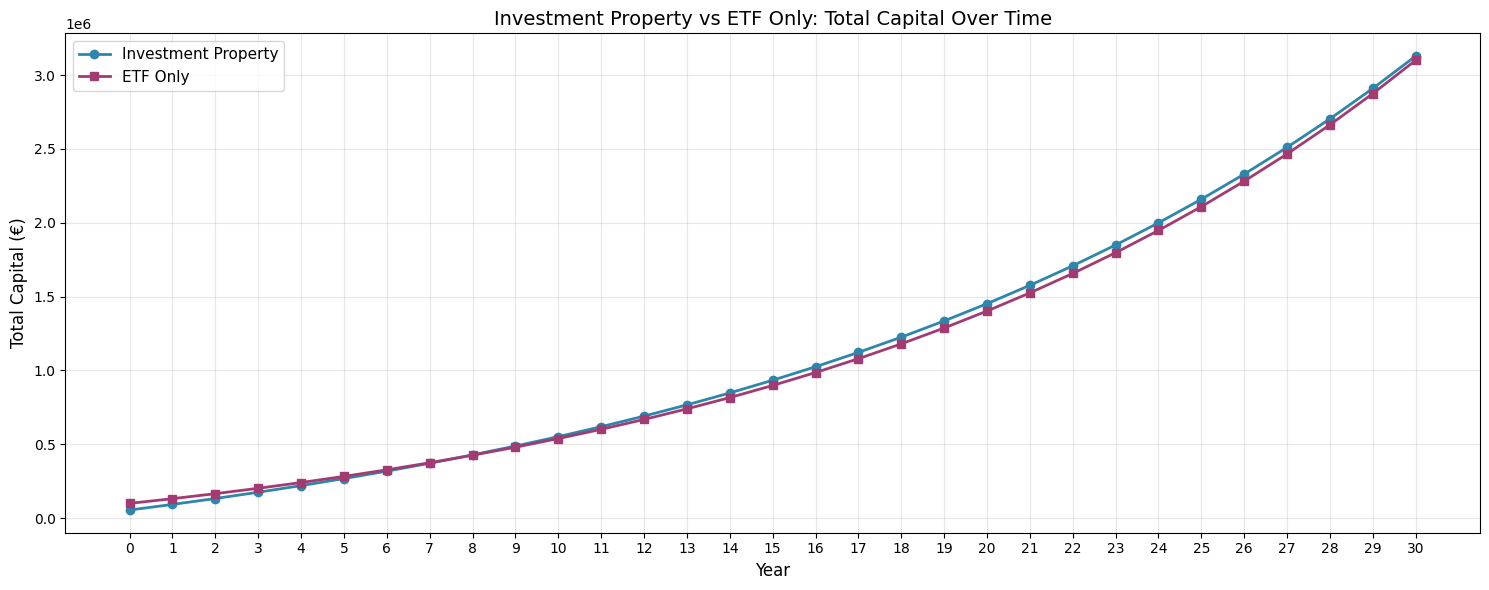

In [9]:
plot_comparison(property_model, etf_model)

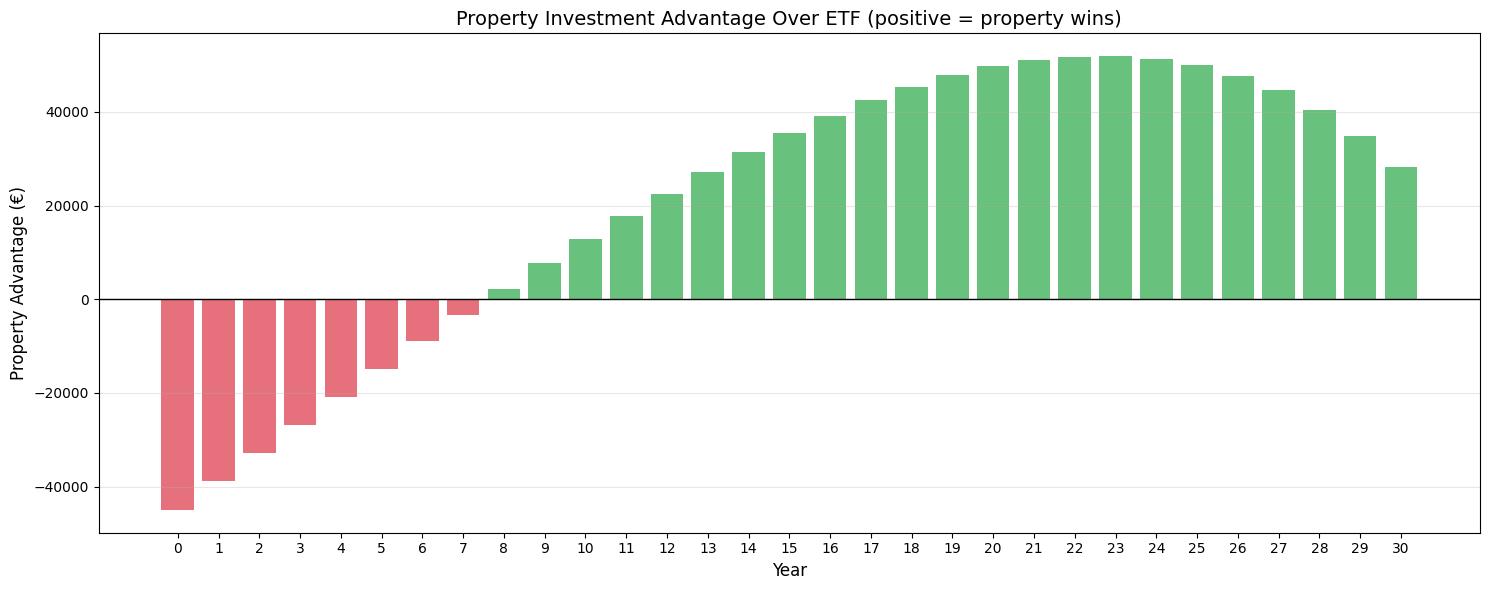

In [10]:
plot_difference(property_model, etf_model)

## Analysis: Breakeven and Final Comparison

In [11]:
# Find breakeven year (when property starts winning)
diff = property_model["estimated_total_capital"] - etf_model["estimated_total_capital"]

breakeven_years = property_model[diff >= 0]["year"].tolist()
if breakeven_years:
    first_breakeven = breakeven_years[0]
    print(f"Property investment breaks even with ETF at year {first_breakeven}")
else:
    print("Property investment never catches up to ETF in the simulation period")

# Final comparison
final_property = property_model["estimated_total_capital"].iloc[-1]
final_etf = etf_model["estimated_total_capital"].iloc[-1]
final_diff = final_property - final_etf

print(f"\nAfter {YEARS} years:")
print(f"  Investment Property: €{final_property:,.0f}")
print(f"  ETF Only:            €{final_etf:,.0f}")
print(f"  Difference:          €{final_diff:,.0f} ({'Property wins' if final_diff > 0 else 'ETF wins'})")

Property investment breaks even with ETF at year 8

After 30 years:
  Investment Property: €3,128,405
  ETF Only:            €3,100,131
  Difference:          €28,274 (Property wins)


## Property Model Details

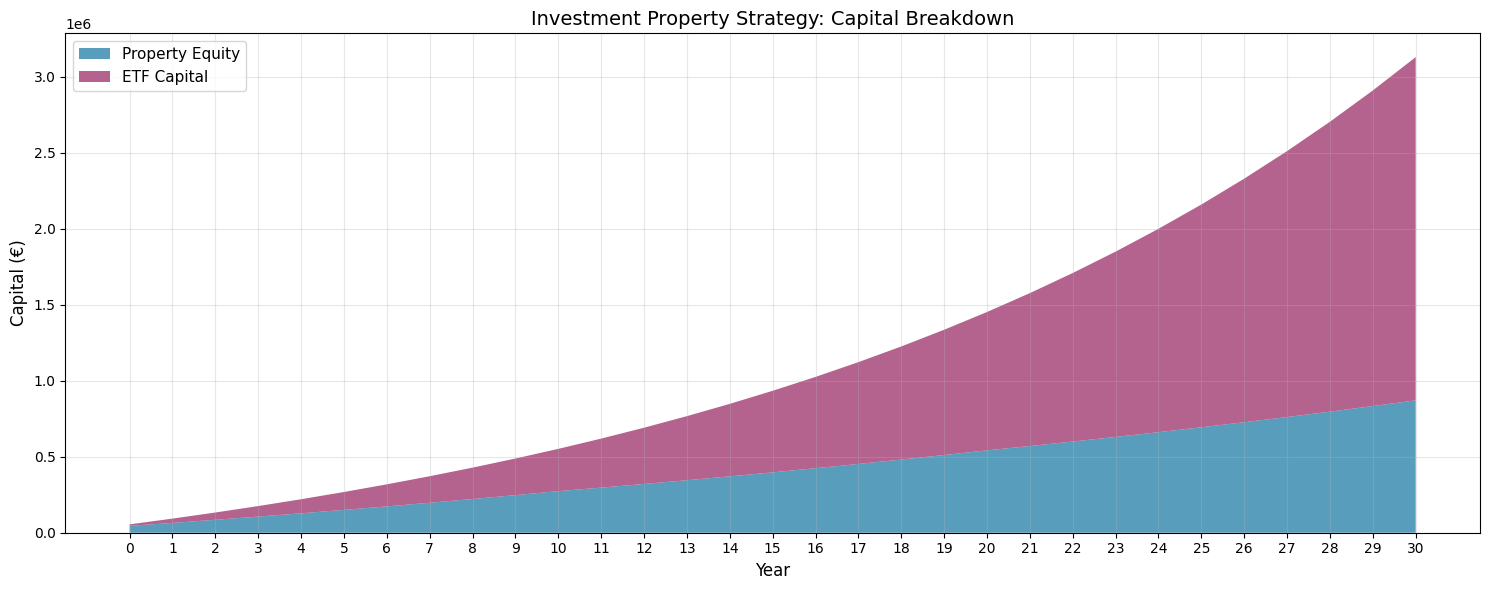

In [12]:
def plot_property_breakdown(property_df):
    """Show property equity vs ETF capital breakdown."""
    years = property_df["year"]
    
    plt.figure(figsize=(15, 6))
    plt.stackplot(
        years,
        property_df["property_equity"],
        property_df["etf_capital"],
        labels=["Property Equity", "ETF Capital"],
        colors=["#2E86AB", "#A23B72"],
        alpha=0.8
    )
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Capital (€)", fontsize=12)
    plt.title("Investment Property Strategy: Capital Breakdown", fontsize=14)
    plt.xticks(years)
    plt.legend(loc="upper left", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_property_breakdown(property_model)

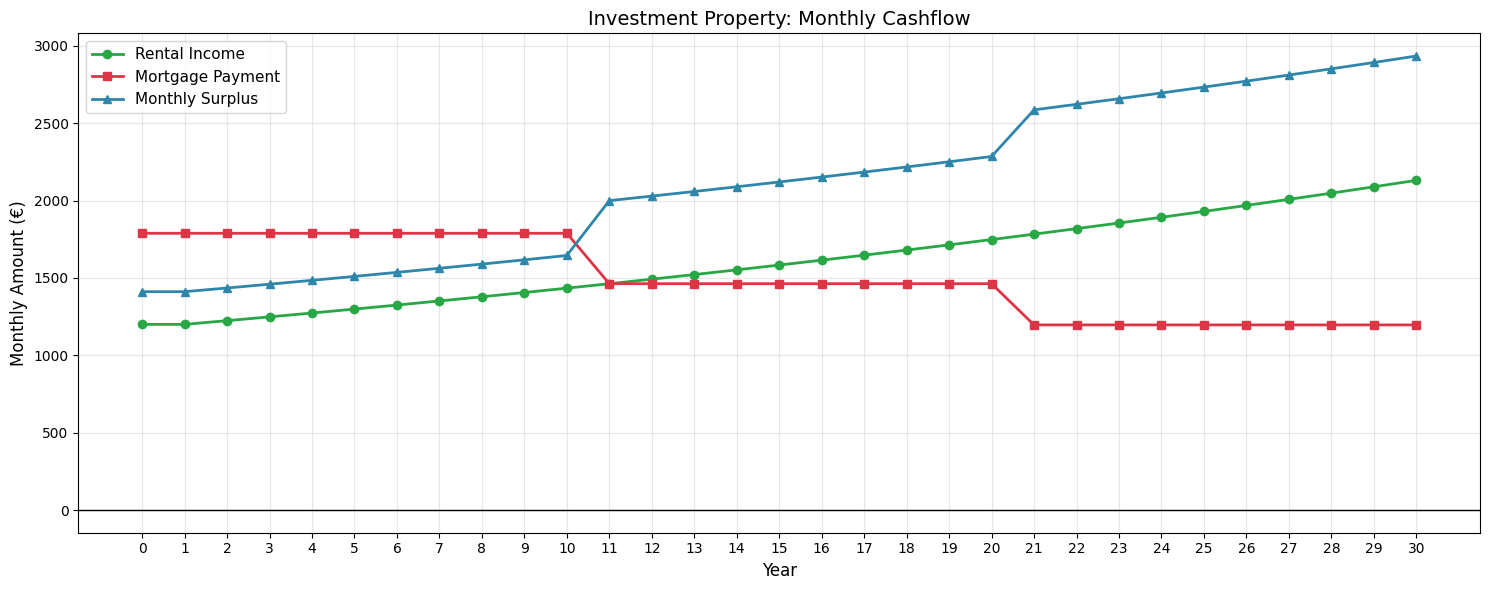

In [13]:
def plot_cashflow(property_df):
    """Show monthly cashflow: rental income vs mortgage payment."""
    years = property_df["year"]
    
    plt.figure(figsize=(15, 6))
    plt.plot(years, property_df["monthly_rental_income"], label="Rental Income", color="#28A745", marker='o', linewidth=2)
    plt.plot(years, property_df["monthly_mortgage_payment"], label="Mortgage Payment", color="#DC3545", marker='s', linewidth=2)
    plt.plot(years, property_df["monthly_surplus"], label="Monthly Surplus", color="#2E86AB", marker='^', linewidth=2)
    
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Monthly Amount (€)", fontsize=12)
    plt.title("Investment Property: Monthly Cashflow", fontsize=14)
    plt.xticks(years)
    plt.axhline(0, color="black", linewidth=1)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_cashflow(property_model)

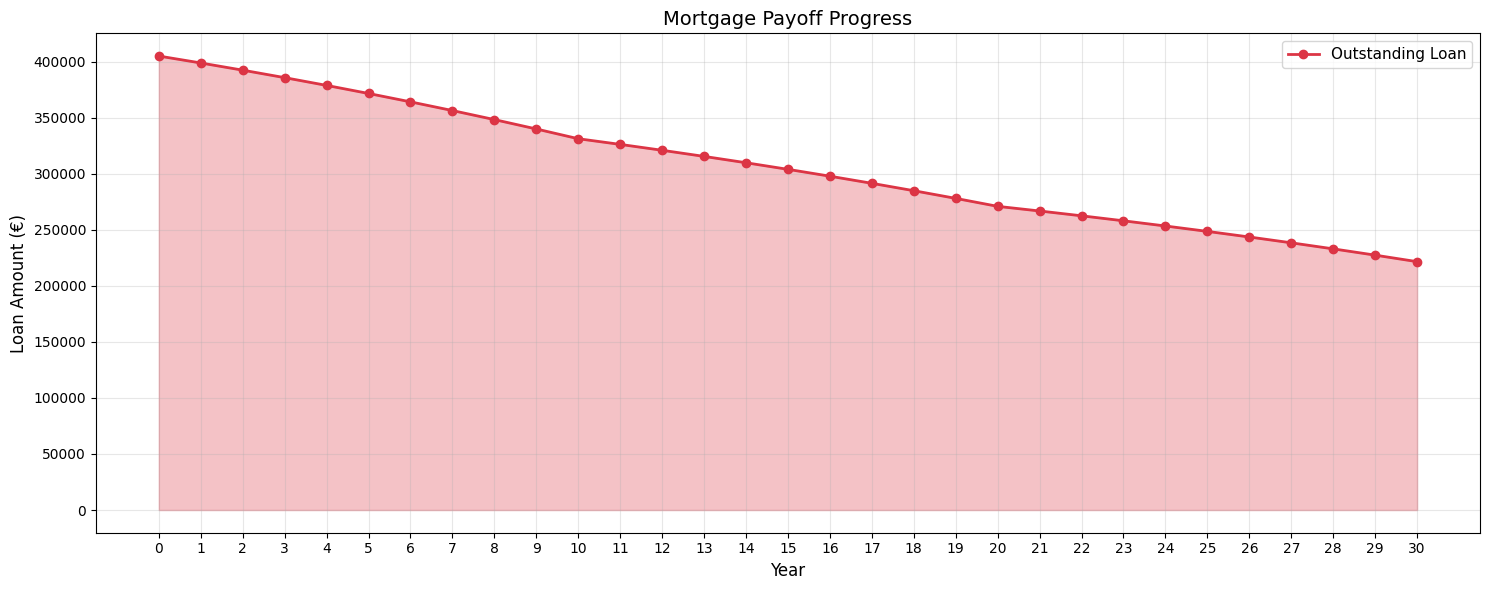

In [14]:
def plot_loan_payoff(property_df):
    """Show loan outstanding over time."""
    years = property_df["year"]
    
    plt.figure(figsize=(15, 6))
    plt.fill_between(years, property_df["total_loan"], alpha=0.3, color="#DC3545")
    plt.plot(years, property_df["total_loan"], label="Outstanding Loan", color="#DC3545", marker='o', linewidth=2)
    
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Loan Amount (€)", fontsize=12)
    plt.title("Mortgage Payoff Progress", fontsize=14)
    plt.xticks(years)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_loan_payoff(property_model)